# Mucin Analysis in Trypanosoma theileri
## data sources

<ul>
    <li>25 genes from trytripDB found by text query with mucin.</li>
    <li>1066 genes from Mark Carrington <a href="https://academic.oup.com/gbe/article/9/8/2093/4082764#supplementary-data">paper</a> using family ids OG0000004, OG0000013, OG0000108, OG0000031 and
         gene ids in Sup Table 2.</li>
    <li> 
    Search results can be visualized in 
        <a href="https://tritrypdb.org/tritrypdb/im.do?s=4c3633527f2df73b">here</a>.</li>
    <li>GPI anchor prediction from: 
        <ul>
            <li>
        <a href="http://gpcr.biocomp.unibo.it/predgpi/pred.htm">PredGPI</a>.
            </li>
            <li>
        <a href="http://mendel.imp.ac.at/gpi/gpi_server.html">big-PI </a> (Metazoa and Protozoa).
            </li>
            
            
       </ul>      
    </li> 
    
</ul> 




In [29]:
#libraries
import pandas as pd
import numpy as np
from Bio import SeqIO
import gc
#visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import missingno as msno
%matplotlib inline
in_data='in_data_theileri/'

In [30]:
#load protein_sequences
records = list(SeqIO.parse(open(in_data+'sequences.fasta', "r"), "fasta"))
#and index the sequences with the gene id
record_dict = {}
for record in records:
    record_dict[record.id]=str(record.seq)
    
del records
gc.collect()

2222

In [31]:

#test
#record_dict['TM35_000012380']

In [32]:
df = pd.read_table(in_data+'sequence.txt')
df=df.iloc[:,0:-1]
print (df.shape)
df.head()

(1085, 7)


,[Gene ID],[Genomic Location (Gene)],[Product Description],[# Transcripts],[CDS Length],[# TM Domains],[SignalP Scores]
0,TM35_000012380,"NBCO01000001:370,282..371,136(-)",hypothetical protein,1,855,0,"NN Sum: 4, NN D: .93, HMM Prob: 1"
1,TM35_000015710,"NBCO01000001:1,230,779..1,231,510(-)",putative mucin TcMUCII,1,732,1,"NN Sum: 3, NN D: .4, HMM Prob: .48"
2,TM35_000016370,"NBCO01000001:1,371,038..1,371,598(-)",hypothetical protein,1,561,1,"NN Sum: 4, NN D: .86, HMM Prob: 1"
3,TM35_000023330,"NBCO01000002:617,931..619,484(+)",putative mucin-associated surface protein (MASP),1,1554,1,"NN Sum: 4, NN D: .89, HMM Prob: 1"
4,TM35_000023720,"NBCO01000002:738,536..739,243(+)",hypothetical protein,1,708,0,NaN


we have a dataframe with  1085 proteins

In [33]:
#let's format better the signal ip scores
def parse_signal_ip(X):
    if str(X).strip() != str(np.nan):
        temp = [n.strip() for n in X.split(', ')]
        score_a = float(temp[0].split(':')[1].strip())
        score_b = float(temp[1].split(':')[1].strip())   
        score_c = float(temp[2].split(':')[1].strip())
        return score_a,score_b,score_c
    else:
        return 0, 0, 0

df["sig_a"], df["sig_b"], df["sig_c"] = zip(*df['[SignalP Scores]'].apply(lambda val: parse_signal_ip(val)))
del df['[SignalP Scores]']

#delete number of transcripts and genomic location
del df['[# Transcripts]']
del df['[Genomic Location (Gene)]']
df.head()

,[Gene ID],[Product Description],[CDS Length],[# TM Domains],sig_a,sig_b,sig_c
0,TM35_000012380,hypothetical protein,855,0,4.0,0.93,1.00
1,TM35_000015710,putative mucin TcMUCII,732,1,3.0,0.40,0.48
2,TM35_000016370,hypothetical protein,561,1,4.0,0.86,1.00
3,TM35_000023330,putative mucin-associated surface protein (MASP),1554,1,4.0,0.89,1.00
4,TM35_000023720,hypothetical protein,708,0,0.0,0.00,0.00


we have now added the signal ip scores from trytripDB

In [34]:
#add aminoacid frequency
def get_frequncy(aa, prot):
    freq = float(prot.count(aa))/len(prot)
    return freq
#test
#get_frequncy('P', record_dict['TM35_000012380'])

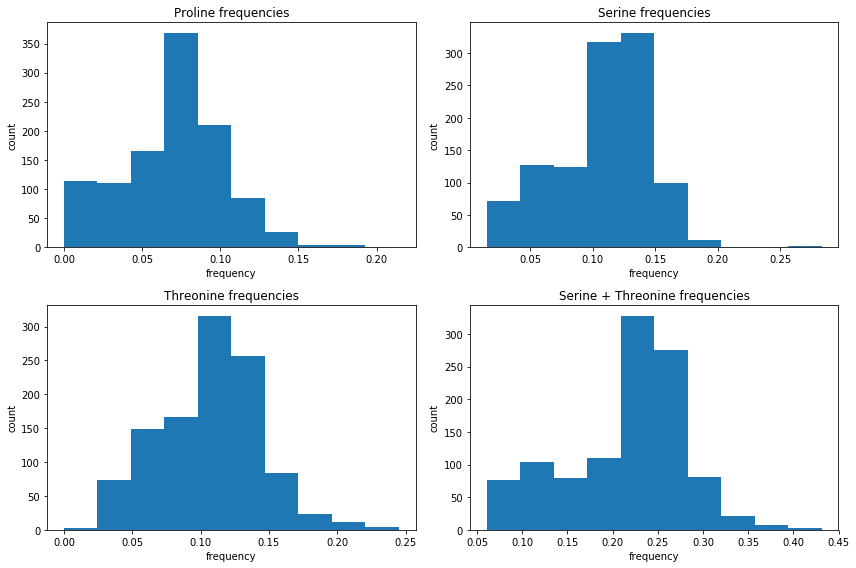

,[Gene ID],[Product Description],[CDS Length],[# TM Domains],sig_a,sig_b,sig_c,P_freq,S_freq,T_freq,ST_freq
0,TM35_000012380,hypothetical protein,855,0,4.0,0.93,1.00,0.017606,0.056338,0.056338,0.112676
1,TM35_000015710,putative mucin TcMUCII,732,1,3.0,0.40,0.48,0.061728,0.065844,0.053498,0.119342
2,TM35_000016370,hypothetical protein,561,1,4.0,0.86,1.00,0.134409,0.064516,0.059140,0.123656
3,TM35_000023330,putative mucin-associated surface protein (MASP),1554,1,4.0,0.89,1.00,0.073501,0.092843,0.056093,0.148936
4,TM35_000023720,hypothetical protein,708,0,0.0,0.00,0.00,0.016949,0.029661,0.076271,0.105932


In [35]:
df['P_freq'] = [get_frequncy('P', record_dict[gene]) for gene in df['[Gene ID]']]
df['S_freq'] = [get_frequncy('S', record_dict[gene]) for gene in df['[Gene ID]']]
df['T_freq'] = [get_frequncy('T', record_dict[gene]) for gene in df['[Gene ID]']]
df['ST_freq'] = df['S_freq']+df['T_freq']

fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(12,8))
df['P_freq'].plot(kind='hist',ax=axes[0,0])
axes[0,0].set_title('Proline frequencies')
axes[0,0].set_xlabel('frequency')
axes[0,0].set_ylabel('count')

df['S_freq'].plot(kind='hist',ax=axes[0,1])
axes[0,1].set_title('Serine frequencies')
axes[0,1].set_xlabel('frequency')
axes[0,1].set_ylabel('count')

df['T_freq'].plot(kind='hist',ax=axes[1,0])
axes[1,0].set_title('Threonine frequencies')
axes[1,0].set_xlabel('frequency')
axes[1,0].set_ylabel('count')

df['ST_freq'].plot(kind='hist',ax=axes[1,1])
axes[1,1].set_title('Serine + Threonine frequencies')
axes[1,1].set_xlabel('frequency')
axes[1,1].set_ylabel('count')
plt.tight_layout()
plt.show()
df.head()

The aminoacid frequency plots can help to select a threshold

In [36]:
#add gpi anchor prediction from PredGPI
#parse result table
def parse_gpi(infile):
    res = {}
    for l in open(infile):
        if l.startswith('TM35_'):
            gene_id = l.split(' ')[0]
            pred = float(l.split('\t')[2].replace('%',''))
            site = int(l.split('\t')[1])
            res[gene_id]=(site,pred)
    return res
gpi_dict =  parse_gpi(in_data+'PredGPI - GPI-anchor Predictor.txt')

In [37]:
def get_score(gene_id):
    return gpi_dict[gene_id]
df["PredGPI_site"], df["PredGPI_score"] = zip(*df['[Gene ID]'].apply(get_score))

,[Gene ID],[Product Description],[CDS Length],[# TM Domains],sig_a,sig_b,sig_c,P_freq,S_freq,T_freq,ST_freq,PredGPI_site,PredGPI_score
0,TM35_000012380,hypothetical protein,855,0,4.0,0.93,1.00,0.017606,0.056338,0.056338,0.112676,257,100.0
1,TM35_000015710,putative mucin TcMUCII,732,1,3.0,0.40,0.48,0.061728,0.065844,0.053498,0.119342,212,6.3
2,TM35_000016370,hypothetical protein,561,1,4.0,0.86,1.00,0.134409,0.064516,0.059140,0.123656,162,0.0
3,TM35_000023330,putative mucin-associated surface protein (MASP),1554,1,4.0,0.89,1.00,0.073501,0.092843,0.056093,0.148936,493,50.7
4,TM35_000023720,hypothetical protein,708,0,0.0,0.00,0.00,0.016949,0.029661,0.076271,0.105932,210,28.0


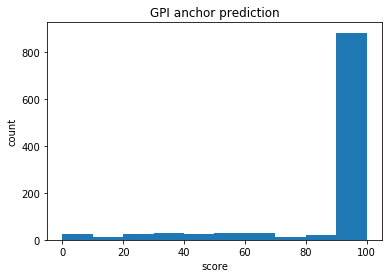

In [38]:
ax=df["PredGPI_score"].plot(kind='hist')
ax.set_xlabel('score')
ax.set_ylabel('count')
ax.set_title('GPI anchor prediction')
df.head()

The majority of the proteins have a high score prediction for a GPI anchor

In [39]:
#add gpi anchor prediction from big-PI
#parse result table

def parse_gpi(infile):
    read_file = open(infile).readlines()
    for index,l in enumerate(read_file):
        if l.startswith('Query sequence '):
            gene_id = l.split(' ')[2].strip()
        if l.startswith('Potential GPI'):
            position = read_file[index+2].split()[-1]
            score = read_file[index+3].split()[-1].replace(')','')
            yield (gene_id, position, score)

gpi_dict = {}
for n in parse_gpi(in_data+'bigp_proto.txt'):
    gpi_dict[n[0]]=(n[1],n[2])
    
def get_score(gene_id):
    if gene_id in gpi_dict:
        return gpi_dict[gene_id]
    else:
        return ('none',1)
        
df["bigp_protozoa_site"], df["bigp_protozoa_score"] = zip(*df['[Gene ID]'].apply(get_score))
df["bigp_protozoa_score"] = -np.log10(df["bigp_protozoa_score"].astype(float))
gpi_dict = {}
for n in parse_gpi(in_data+'bigpi_meta.txt'):
    gpi_dict[n[0]]=(n[1],n[2])
df["bigp_metazoa_site"], df["bigp_metazoa_score"] = zip(*df['[Gene ID]'].apply(get_score))
df["bigp_metazoa_score"] = -np.log10(df["bigp_metazoa_score"].astype(float))

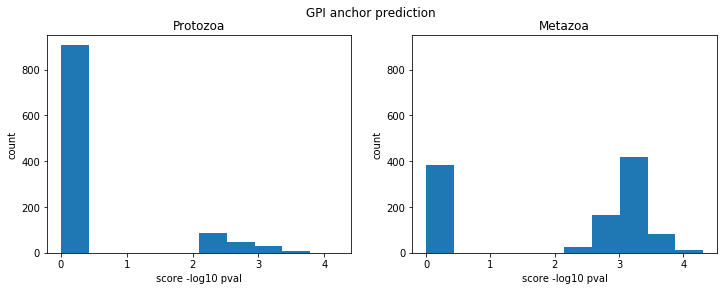

In [40]:
#less prediction from protozoa respect to metazoa?
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
df["bigp_protozoa_score"].plot(kind='hist',ax=axes[0])
axes[0].set_xlabel('score -log10 pval')
axes[0].set_ylabel('count')
axes[0].set_title('Protozoa')
axes[0].set_ylim(0,950)
df["bigp_metazoa_score"].plot(kind='hist',ax=axes[1])
axes[1].set_xlabel('score -log10 pval')
axes[1].set_ylabel('count')
axes[1].set_title('Metazoa')
axes[1].set_ylim(0,950)
plt.suptitle('GPI anchor prediction')
plt.show()

In [41]:
#df.plot(kind='scatter',x='PredGPI_score',y='bigp_metazoa_score')

In [42]:
df.head()

,[Gene ID],[Product Description],[CDS Length],[# TM Domains],sig_a,sig_b,sig_c,P_freq,S_freq,T_freq,ST_freq,PredGPI_site,PredGPI_score,bigp_protozoa_site,bigp_protozoa_score,bigp_metazoa_site,bigp_metazoa_score
0,TM35_000012380,hypothetical protein,855,0,4.0,0.93,1.00,0.017606,0.056338,0.056338,0.112676,257,100.0,none,-0.00000,262,3.000846
1,TM35_000015710,putative mucin TcMUCII,732,1,3.0,0.40,0.48,0.061728,0.065844,0.053498,0.119342,212,6.3,none,-0.00000,none,-0.000000
2,TM35_000016370,hypothetical protein,561,1,4.0,0.86,1.00,0.134409,0.064516,0.059140,0.123656,162,0.0,166,2.97576,166,2.912663
3,TM35_000023330,putative mucin-associated surface protein (MASP),1554,1,4.0,0.89,1.00,0.073501,0.092843,0.056093,0.148936,493,50.7,none,-0.00000,none,-0.000000
4,TM35_000023720,hypothetical protein,708,0,0.0,0.00,0.00,0.016949,0.029661,0.076271,0.105932,210,28.0,none,-0.00000,none,-0.000000


## Add proteomic data
Rupa produced proteomic data using an extract of external proteins in Trypanosoma theileri. We add now this information to the dataframe

In [15]:
#get only the gene id from
#the new TryTripDB format
def clean_id(temp_id):
    temp_id = temp_id.split('-')[0]
    return temp_id

#lets see if the proteins are identified in Rupa mass spec data
#helper function to print out
#the protein removed at each threshold
def print_result(start_df_shape, shape_before, df, what):
    removed = shape_before[0]- df.shape[0]
    removed_from_beginning = start_df_shape[0]-df.shape[0]
    if removed > 0:
        print ('removed ',removed, what )  
        print ('tot ', removed_from_beginning, ' entries removed' )
        print ('---------------')
    else:
        print (what)
        print ('nothing removed')
        print ('---------------')

#remove rubbish entires from a
#maxquant output
def clean(df):  
    #remove Only identified by site
    before,start = df.shape,df.shape
    col = 'Only identified by site'
    df = df[df[col] != '+'] 
    print_result(start, before, df, col)
    
    #remove hits from reverse database
    before = df.shape
    col = 'Reverse'
    df = df[df[col] != '+']
    print_result(start, before, df, col)
        
    #remove contaminants (mainly keratine and bsa)
    before = df.shape
    col = 'Potential contaminant'
    df = df[df[col] != '+']
    print_result(start, before, df, col)
    return df

#read data 
proteomic_df = pd.read_csv(in_data+'combined_Trypanosoma_theileri_prot/txt/proteinGroups.txt',sep='\t')
proteomic_df = clean(proteomic_df)

proteomic_df['[Gene ID]']=[clean_id(n) for n in proteomic_df['Protein IDs']]
proteomic_df.set_index('[Gene ID]',inplace=True)
proteomic_df = proteomic_df[['Peptide counts (unique)','Score','Intensity','MS/MS count']]
df.set_index('[Gene ID]',inplace=True)
df=df.join(proteomic_df, how='left')
df['prot_len']=df['[CDS Length]']/3
df.to_csv('out_theileri.csv')

removed  16 Only identified by site
tot  16  entries removed
---------------
removed  13 Reverse
tot  29  entries removed
---------------
removed  26 Potential contaminant
tot  55  entries removed
---------------


In [16]:
df.head()

,[Product Description],[CDS Length],[# TM Domains],sig_a,sig_b,sig_c,P_freq,S_freq,T_freq,ST_freq,...,PredGPI_score,bigp_protozoa_site,bigp_protozoa_score,bigp_metazoa_site,bigp_metazoa_score,Peptide counts (unique),Score,Intensity,MS/MS count,prot_len
[Gene ID],,,,,,,,,,,,,,,,,,,,,
TM35_000012380,hypothetical protein,855,0,4.0,0.93,1.00,0.017606,0.056338,0.056338,0.112676,...,100.0,none,-0.00000,262,3.000846,6,48.086,19757000.0,8.0,285.0
TM35_000015710,putative mucin TcMUCII,732,1,3.0,0.40,0.48,0.061728,0.065844,0.053498,0.119342,...,6.3,none,-0.00000,none,-0.000000,NaN,NaN,NaN,NaN,244.0
TM35_000016370,hypothetical protein,561,1,4.0,0.86,1.00,0.134409,0.064516,0.059140,0.123656,...,0.0,166,2.97576,166,2.912663,NaN,NaN,NaN,NaN,187.0
TM35_000023330,putative mucin-associated surface protein (MASP),1554,1,4.0,0.89,1.00,0.073501,0.092843,0.056093,0.148936,...,50.7,none,-0.00000,none,-0.000000,NaN,NaN,NaN,NaN,518.0
TM35_000023720,hypothetical protein,708,0,0.0,0.00,0.00,0.016949,0.029661,0.076271,0.105932,...,28.0,none,-0.00000,none,-0.000000,NaN,NaN,NaN,NaN,236.0


In [17]:
df['Score'].isna().value_counts()

False    612
True     473
Name: Score, dtype: int64

612 proteins are identified in the mass spectrometry data

In [18]:
df.head()

,[Product Description],[CDS Length],[# TM Domains],sig_a,sig_b,sig_c,P_freq,S_freq,T_freq,ST_freq,...,PredGPI_score,bigp_protozoa_site,bigp_protozoa_score,bigp_metazoa_site,bigp_metazoa_score,Peptide counts (unique),Score,Intensity,MS/MS count,prot_len
[Gene ID],,,,,,,,,,,,,,,,,,,,,
TM35_000012380,hypothetical protein,855,0,4.0,0.93,1.00,0.017606,0.056338,0.056338,0.112676,...,100.0,none,-0.00000,262,3.000846,6,48.086,19757000.0,8.0,285.0
TM35_000015710,putative mucin TcMUCII,732,1,3.0,0.40,0.48,0.061728,0.065844,0.053498,0.119342,...,6.3,none,-0.00000,none,-0.000000,NaN,NaN,NaN,NaN,244.0
TM35_000016370,hypothetical protein,561,1,4.0,0.86,1.00,0.134409,0.064516,0.059140,0.123656,...,0.0,166,2.97576,166,2.912663,NaN,NaN,NaN,NaN,187.0
TM35_000023330,putative mucin-associated surface protein (MASP),1554,1,4.0,0.89,1.00,0.073501,0.092843,0.056093,0.148936,...,50.7,none,-0.00000,none,-0.000000,NaN,NaN,NaN,NaN,518.0
TM35_000023720,hypothetical protein,708,0,0.0,0.00,0.00,0.016949,0.029661,0.076271,0.105932,...,28.0,none,-0.00000,none,-0.000000,NaN,NaN,NaN,NaN,236.0


In [19]:
proteomic_df['in_list']=[1 if n in df.index.values else 0 for n in proteomic_df.index.values]

In [20]:
proteomic_df['in_list'].value_counts()

0    679
1    612
Name: in_list, dtype: int64

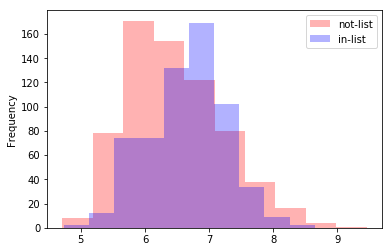

In [21]:
proteomic_df=proteomic_df[proteomic_df['Intensity']>0]
fig,ax=plt.subplots()
np.log10(proteomic_df[proteomic_df['in_list']==0]['Intensity']).plot(kind='hist',ax=ax,color='r',label='not-list',alpha=0.3)
np.log10(proteomic_df[proteomic_df['in_list']==1]['Intensity']).plot(kind='hist',ax=ax,color='b',label='in-list',alpha=0.3)
plt.legend()
plt.show()

removed  16 Only identified by site
tot  16  entries removed
---------------
removed  13 Reverse
tot  29  entries removed
---------------
removed  26 Potential contaminant
tot  55  entries removed
---------------


d:\my_env\prediction\lib\site-packages\ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in log10
  from ipykernel import kernelapp as app


225


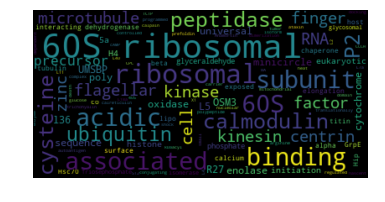

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_gene_desc(headers):
    temp = []
    for item in headers.split(' | '):
        if 'gene_product=' in item:
            temp.append(item.split('=')[1].strip())
    return ' '.join(temp)
proteomic_df = pd.read_csv(in_data+'combined_Trypanosoma_theileri_prot/txt/proteinGroups.txt',sep='\t')
proteomic_df = clean(proteomic_df)
proteomic_df['desc']=proteomic_df['Fasta headers'].apply(get_gene_desc)
proteomic_df.head()

desc = proteomic_df[np.log10(proteomic_df['Intensity'])>7.2]['desc']
print (len(desc))
desc = [n for n in desc if n not in ['hypothetical protein']]
desc = [n.replace('protein,','') for n in desc]
desc = [n.replace('protein','') for n in desc]
desc = [n.replace('putative','') for n in desc]
text = ' '.join(desc)

# lower max_font_size
wordcloud = WordCloud(max_font_size=40).generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()